In [346]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
import emcee
import corner

Text(0, 0.5, '$flux$')

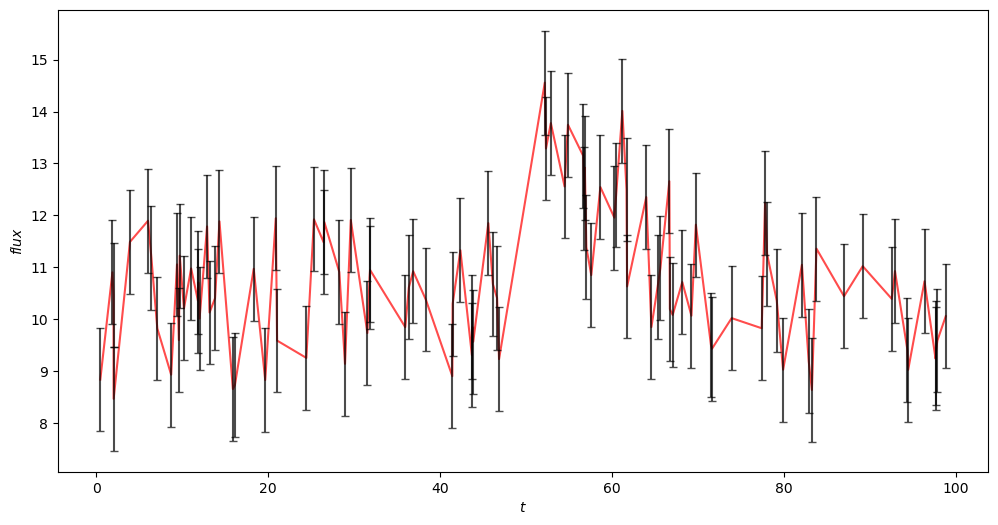

In [347]:
data = np.load('transient.npy')

#getting the columns from the data matrix
t_vals = data[:, 0]
flux_vals = data[:, 1]
errs = data[:, 2]

#preliminary plot of the data
plt.figure(figsize=(12, 6))
plt.plot(t_vals, flux_vals, c='r', alpha=0.7)
plt.errorbar(t_vals, flux_vals, yerr=errs, fmt='none', c='black', capsize=3, alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$flux$')


In [348]:

def model(x, t):
    #model for the transient phenomenon, assumes a constant background and a signal
    #consisting of a burst with an exponential tail
    b, A, alpha, t_0 = x #parameters of the model (varibles for the posterior)
    return b + np.heaviside(t-t_0, 1)*A*np.exp(-alpha*(t-t_0))

def logLikelihood(x, data):
    #assumes the measurements are subject to gaussian errors
    logL = 0.
    for measure in data:
        mu_i = model(x, measure[0])
        sigma_i = measure[2]
        logL += np.log(norm(mu_i, sigma_i).pdf(measure[1]))
    return logL
    
def logPrior(x):
    #uniform priors for a, A, t0 and the log of alpha
    b, A, alpha, t_0 = x
    if not (0 < b < 50 and 0 < A < 50 and 0 < t_0 < 100 and np.exp(-5) < alpha < np.exp(5)):
        return -np.inf
    
    return np.log((1./50.)*(1./50.)*(1./100.)*(1./(10*x[2])))

def logPosterior(x, data):

        return logLikelihood(x, data) + logPrior(x)




In [256]:
#defining the parameters of the chain and running the MCMC 

ndim = 4 # number of parameters
nwalkers = 10 # number of MCMC walkers
nsteps = 80000 # number of steps in the chain (for each walker)

# starting points for each walker
starting_guesses = []
for i in range(nwalkers):
    starting_guesses.append([10.+5*np.random.random(), 4.5+2*np.random.random(), 0.1+0.1*np.random.random(), 50.+10*np.random.random()])

#MCMC
MC_sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[data])
MC_sampler.run_mcmc(starting_guesses, nsteps)

/tmp/ipykernel_28281/2269877192.py:13: RuntimeWarning: divide by zero encountered in log
  logL += np.log(norm(mu_i, sigma_i).pdf(measure[1]))


State([[10.33821561  4.06333163  0.14024722 52.05745166]
 [10.31870602  4.0111191   0.11964684 49.09133253]
 [10.27541985  4.67555799  0.11959155 51.41679782]
 [10.51523845  6.51751474  0.12753961 47.89396539]
 [ 9.99099096  6.17406973  0.11929999 50.25607524]
 [10.49895547  4.65097332  0.13165834 48.47743003]
 [10.15917769  3.7314476   0.09093664 51.58752838]
 [10.19138108  7.39543901  0.10470861 46.96643366]
 [10.41137938  4.05518394  0.12792269 51.64162216]
 [10.2854699   3.91365291  0.10585994 50.7297614 ]], log_prob=[-153.73123487 -156.54303734 -153.88926089 -155.38992385 -157.8478196
 -156.54332723 -153.98638755 -154.47923271 -153.86700587 -153.56157128], blobs=None, random_state=('MT19937', array([4259238845, 3738172058, 3449734754, 3543928065, 2711074421,
        675235037,  437316394, 2163134661, 3287795754, 2778729445,
        826606698, 2393251365, 2562674601, 4098622880, 3193581132,
        582263502, 1838356966, 3037392749, 2846010693, 3654556569,
        111836338, 280368

Text(0.5, 0, '$n_{step}$')

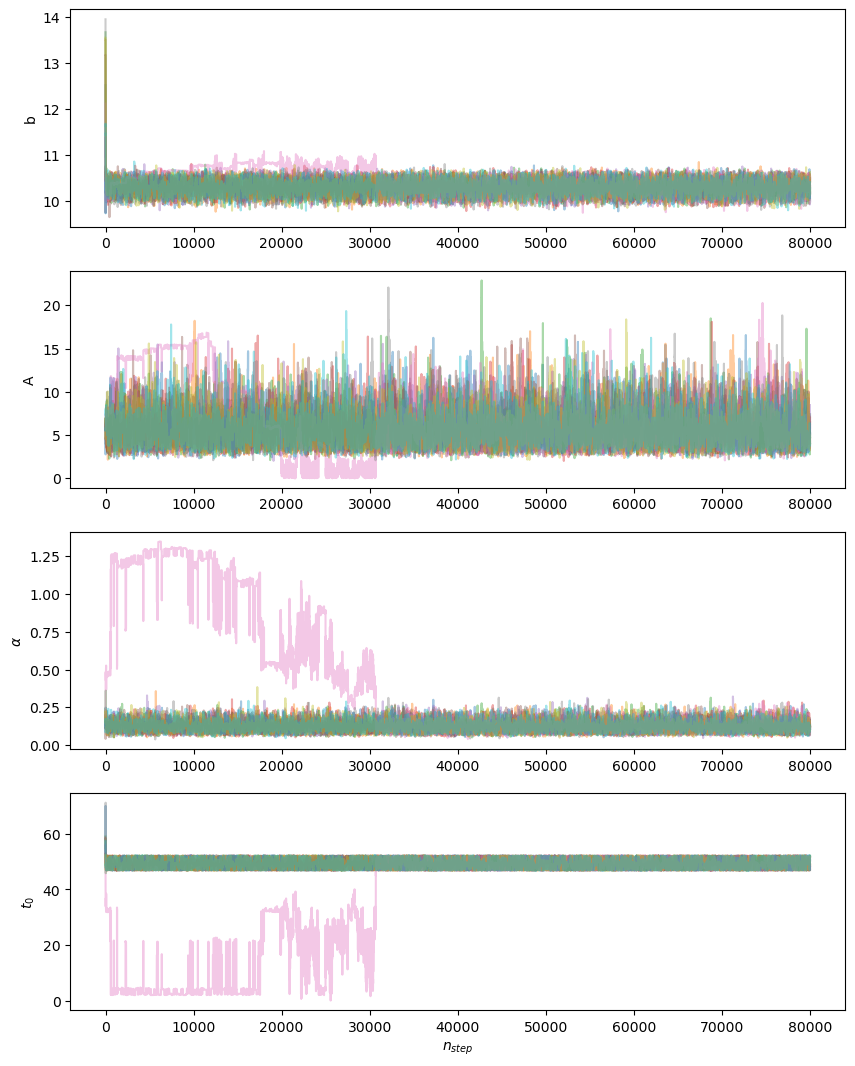

In [281]:
#trace plot of the chain for each parameter, different walkers are associated to diffrent colors
param = ['b', 'A', '$\\alpha$', '$t_{0}$']   
fig, ax = plt.subplots(4, figsize=(10, 13))
for j in range(ndim):
    ax_j = ax[j]
    ax_j.set_ylabel(param[j])
    for i in range(nwalkers):
        ax_j.plot(MC_sampler.chain[i, :, j], alpha=0.4) #change the range in the chain to check the burn in period
ax[-1].set_xlabel('$n_{step}$')
    

In [ ]:
#checking the acceptance rate for each walker
print(MC_sampler.acceptance_fraction)

[0.5098375 0.5130875 0.5055375 0.5098875 0.50775   0.5082125 0.351275
 0.509275  0.5071125 0.511825 ]


There seems to be a problem with the seventh walker, which gets stuck and approximates the equlibrium condition only after a bit less than half of the steps

Text(0.5, 0, '$n_{step}$')

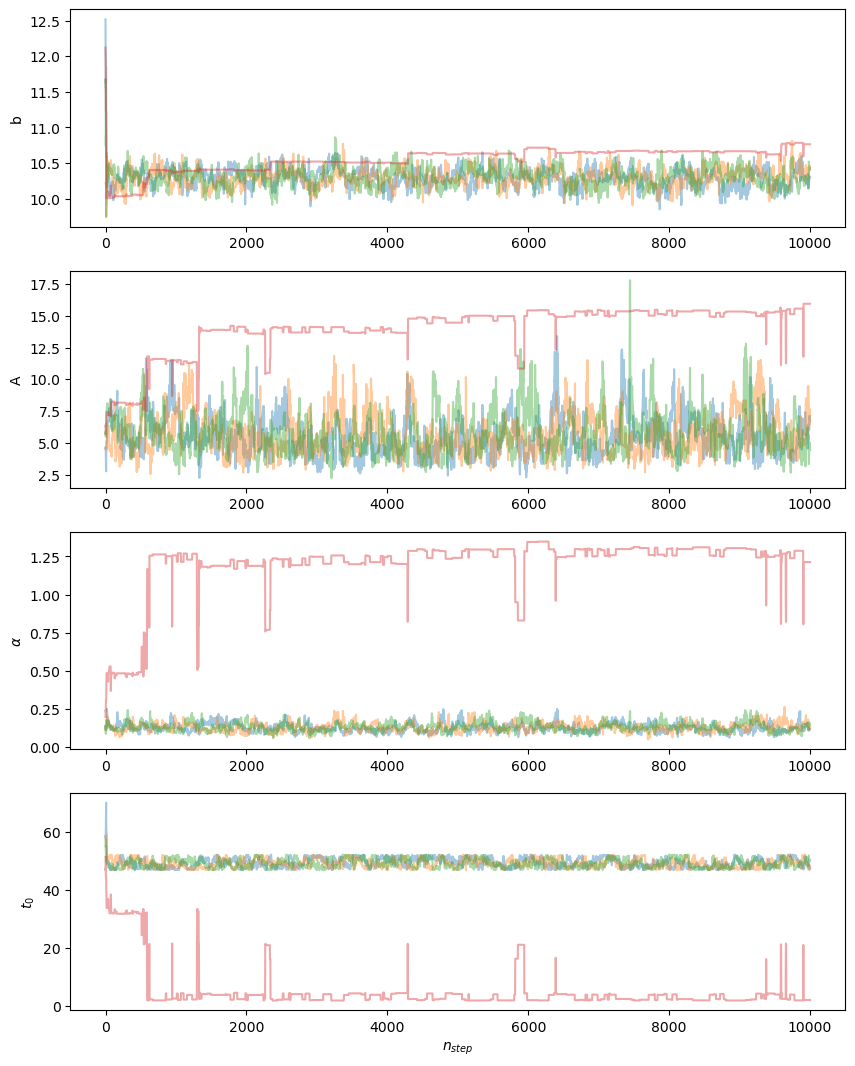

In [284]:
#checking the initial steps of the chain
fig, ax = plt.subplots(4, figsize=(10, 13))
for j in range(ndim):
    ax_j = ax[j]
    ax_j.set_ylabel(param[j])
    example_walkers = [0, 3, 9, 6] # we consider the problematic walker and a few others
    for i in example_walkers:
        ax_j.plot(MC_sampler.chain[i, :10000, j], alpha=0.4)
ax[-1].set_xlabel('$n_{step}$')

For all except the seventh walker the chain seems to be stationary after the first few steps. We discard the problematic walker and for safety (and given the large $n_{steps}$) consider a burn in time of ~ 2000 for all others

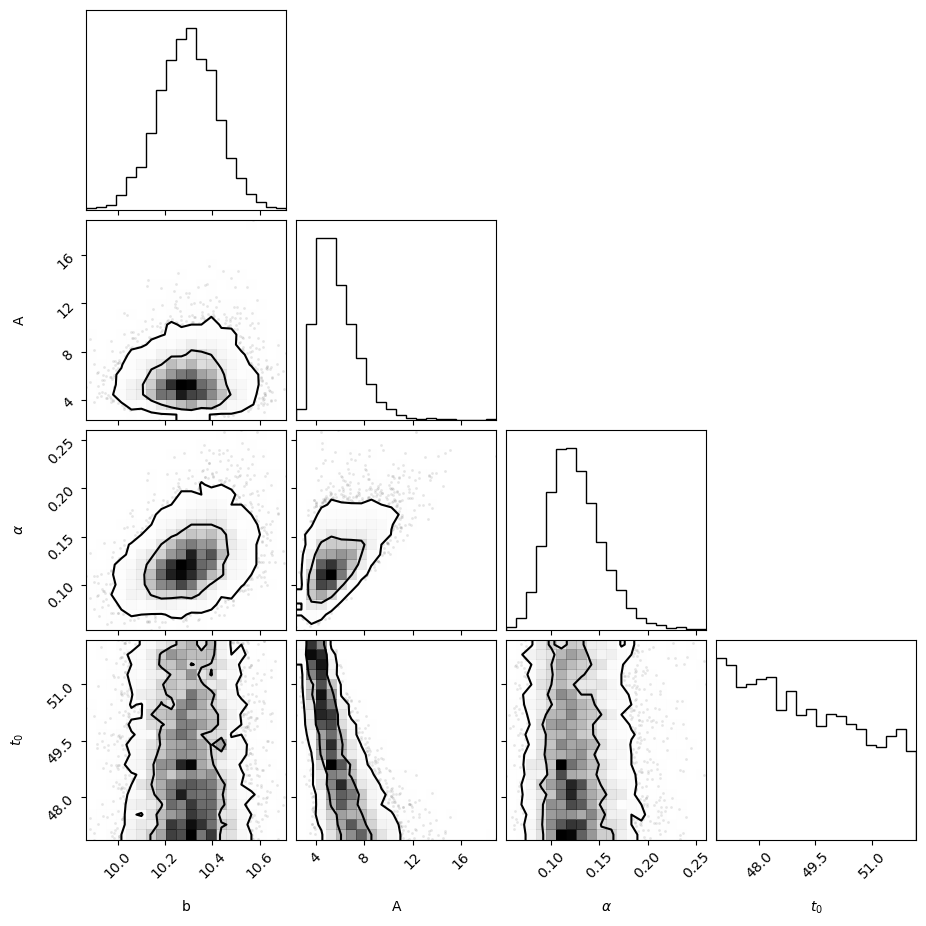

In [323]:
#discarding the stuck walker
good_walkers = [0, 1, 2, 3, 4, 5, 7, 8, 9]
chain = MC_sampler.get_chain()[:, good_walkers, :]

burn = 2000 # burn-in steps 
tau_vect = emcee.autocorr.integrated_time(chain)
tau_max = np.max(tau_vect) # maximum autocorrelation time out of all parameters
thin = int(tau_max+1)

#discarding the burn in steps, thinning according to the autocorrelation time and combining the different walkers
reshaped_chain = chain[burn::thin, :, :]
flat_chain = reshaped_chain.reshape(-1, reshaped_chain.shape[-1])

#making a corner plot of the sampled posterior pdf
corner_plot = corner.corner(flat_chain, labels=param, levels=[0.68, 0.95])


We now take 100 random samples from our chain and plot the corresponding models along with the data

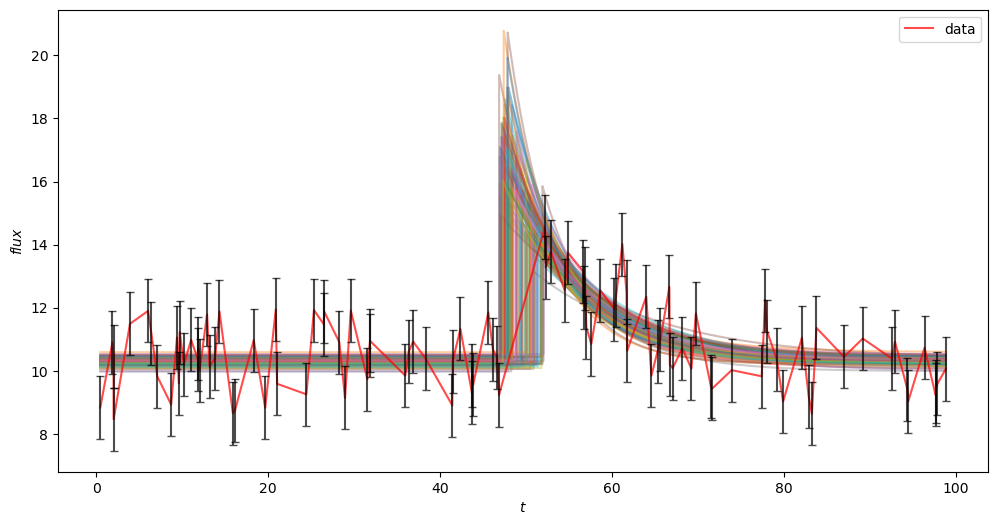

In [ ]:
#choosing 100 random samples 
ran = np.arange(1, len(flat_chain)+1)
rand_samples = [np.random.choice(ran) for i in range(100)]

#plotting the models over the data
plt.figure(figsize=(12, 6))
t_grid = np.linspace(np.min(t_vals), np.max(t_vals), 10000)
for sample in rand_samples:
    x = flat_chain[sample-1, :]
    plt.plot(t_grid, model(x, t_grid), alpha=0.4)
plt.plot(t_vals, flux_vals, c='r', alpha=0.7, label='data')
plt.errorbar(t_vals, flux_vals, yerr=errs, fmt='none', c='black', capsize=3, alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$flux$')
plt.legend()

In [357]:
#computing the median and 90% credible regions
results = [] #stores the medians and the limits of the credible region
median_params = []
labels= ['b', 'A', 'alpha', 't0']

for i in range(len(param)):
    chain_par = flat_chain[:, i]
    median = np.median(chain_par)
    low_limit, up_limit = np.quantile(chain_par, [0.05, 0.95])
    results.append([median, median-low_limit, up_limit-median])
    median_params.append(median)
    print(f"{labels[i]} = {median:.2f} [{low_limit:.2f}, {up_limit:.2f}] (90% CL)")


b = 10.30 [10.09, 10.50] (90% CL)
A = 5.43 [3.61, 8.88] (90% CL)
alpha = 0.12 [0.09, 0.18] (90% CL)
t0 = 49.07 [47.06, 51.82] (90% CL)


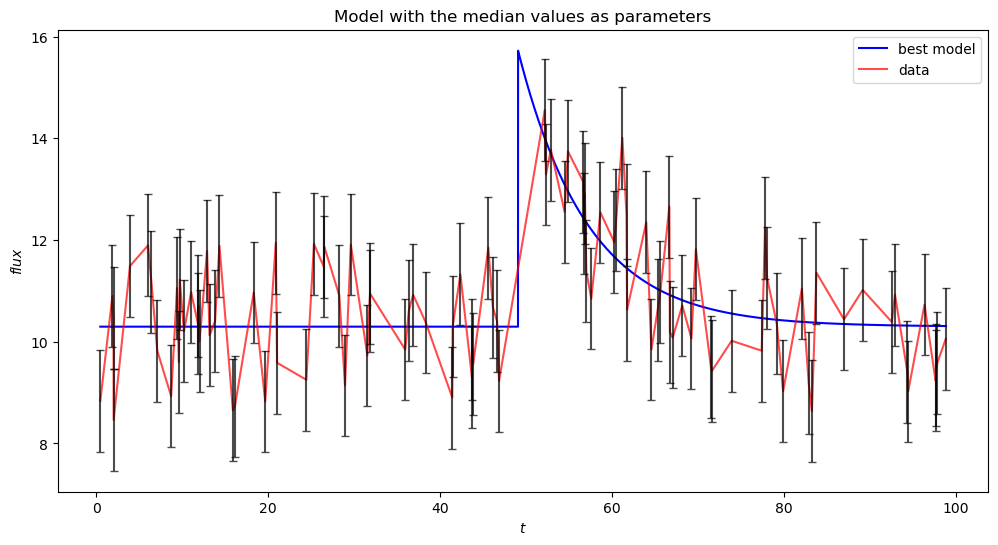

In [367]:
#plotting the model with the median values for the parameters, along with the data
plt.figure(figsize=(12, 6))
plt.plot(t_grid, model(median_params, t_grid), c='b', label='best model')
plt.plot(t_vals, flux_vals, c='r', alpha=0.7, label='data')
plt.errorbar(t_vals, flux_vals, yerr=errs, fmt='none', c='black', capsize=3, alpha=0.7)
plt.xlabel('$t$')
plt.ylabel('$flux$')
plt.title('Model with the median values as parameters')
plt.legend()

From the MCMC sampling of the posterior pdf we report the median values and 90% confidence regions for each parameter: 
$$b = 10.30^{+0.20}_{-0.21}$$
$$A = 5.43^{+3.45}_{-1.82}$$
$$\alpha = 0.12^{+0.06}_{-0.02}$$
$$t_{0} = 49.07^{+2.75}_{-2.01}$$
